# Unsupervised Learning Final Project: NHL Player Clustering

Author: Alex Waddel

Date: 12/7/2025

### Problem Description
In professional hockey, team general managers must assemble a complementary set of ~20 players for their team. It is crucial in hockey to have a variety of players that fulfill different roles on the team. Thus, it may be beneficial to cluster similar types of players in order to gain insights and to help assemble a team with all the roles you need. In this project, I will attempt to use unsupervised learning algorithms in order to cluster NHL players into similar groups.

### Data source
I will use NHL player data from the 2024-2025 regular season. The website MoneyPuck has publicly available data sets for each season. These data sets contain many simple and complex features that we can use for clustering.

https://moneypuck.com/data.htm

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.calibration import LabelEncoder
from sklearn.base import BaseEstimator
from sklearn.model_selection import GridSearchCV
import seaborn as sns


## Load Data / EDA

In [2]:
# Get directory of the current script
script_dir = Path.cwd()
csv_path = script_dir / "data" / "skater_data_2025-2025.csv"
data = pd.read_csv(csv_path)
print("Sample size:", len(data))
print("Number of features:", data.shape[1])
print(data.head(n=7))
print("Feature columns:", data.columns.tolist())

Sample size: 4600
Number of features: 154
   playerId  season             name team position situation  games_played  \
0   8478047    2024  Michael Bunting  NSH        L     other            76   
1   8478047    2024  Michael Bunting  NSH        L       all            76   
2   8478047    2024  Michael Bunting  NSH        L      5on5            76   
3   8478047    2024  Michael Bunting  NSH        L      4on5            76   
4   8478047    2024  Michael Bunting  NSH        L      5on4            76   
5   8480950    2024  Ilya Lyubushkin  DAL        D     other            80   
6   8480950    2024  Ilya Lyubushkin  DAL        D       all            80   

   icetime  shifts  gameScore  ...  OffIce_F_xGoals  OffIce_A_xGoals  \
0   2237.0    37.0      26.19  ...             7.28            10.09   
1  70819.0  1474.0      43.70  ...           161.54           187.75   
2  59813.0  1294.0      43.70  ...           112.73           122.08   
3      6.0     2.0       2.58  ...           

There are 5 rows for each player and a ton of features that we likely don't care about.

Let's only consider 'all' situations of the game for each player. Otherwise there is duplicate data for other situations of the hockey game (5v4, 4v5, etc.)

In [3]:
print("Player sample size before:", len(data))
df = data[data['situation'] == 'all']
print("Player sample size after:", len(df))


Player sample size before: 4600
Player sample size after: 920


We can plot a histogram of the number of games played for each player to check the distribution.

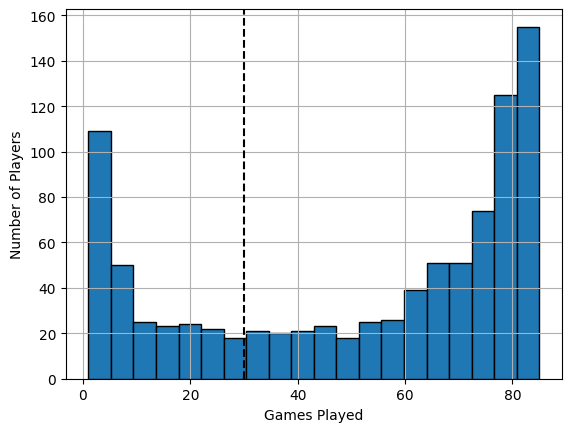

In [4]:
num_games_cutoff = 30
df['games_played'].hist(bins=20, edgecolor='black')
plt.xlabel('Games Played')
plt.ylabel('Number of Players')
plt.axvline(x=num_games_cutoff, color='black', linestyle='--')
plt.show()

Let's only consider players who played 30+ games over the course of the 82 game season. This eliminates some players who are only in the league for a short amount of time that may muddy up the clustering.

In [5]:
print("Player sample size before:", len(df))
df = df[df['games_played'] >= num_games_cutoff]
print("Player sample size after:", len(df))
print("Number of features:", df.shape[1])

Player sample size before: 920
Player sample size after: 655
Number of features: 154


There are 154 features currently. I know that some of these won't be very useful in the clustering model just based on my background with ice hockey. We'll go ahead and manually do some feature selection and feature engineering. The following things we'll do to clean and prepare the data:
- Map player names to player IDs so we can remove names, but reference later
- Manually select features that could be useful in clustering
- Add feature that is ratio of penalties taken to penalties drawn
- Add feature that is percentage of faceoffs won
- For many relevant features, normalize feature by ice time
- Convert any remaining categorical features (position), into numerical data

In [ ]:
# Map player Id to name for easier lookup later
player_id_to_name = dict(zip(df['playerId'], df['name']))

# Change position codes to full strings
position_map = {
    'C': 'Center',
    'L': 'LeftWing',
    'R': 'RightWing',
    'D': 'Defenseman',
}
df['position'] = df['position'].map(position_map)

# Manually select columns we might be interested in
columns_to_keep = [
    'playerId','position', 'icetime','gameScore','onIce_xGoalsPercentage',
    'onIce_corsiPercentage', 'onIce_fenwickPercentage', 'iceTimeRank', 'I_F_xOnGoal',
    'I_F_xGoals', 'I_F_xRebounds', 'I_F_flurryAdjustedxGoals', 'I_F_primaryAssists', 
    'I_F_secondaryAssists', 'I_F_shotsOnGoal', 'I_F_missedShots', 'I_F_blockedShotAttempts', 
    'I_F_shotAttempts', 'I_F_points', 'I_F_goals', 'I_F_rebounds', 'I_F_reboundGoals',
    'penalties', 'I_F_hits', 'I_F_takeaways', 'I_F_giveaways', 
    'I_F_scoreAdjustedShotsAttempts', 'I_F_dZoneGiveaways',
    'I_F_reboundxGoals', 'I_F_oZoneShiftStarts', 'I_F_dZoneShiftStarts', 'I_F_neutralZoneShiftStarts', 
    'I_F_flyShiftStarts', 'faceoffsWon', 'faceoffsLost', 'penaltiesDrawn', 'shotsBlockedByPlayer',
    'OnIce_F_xGoals', 'OnIce_F_flurryAdjustedxGoals', 'OnIce_F_shotsOnGoal', 'OnIce_F_goals',
]
# Subset `df` to only the existing columns
df = df[columns_to_keep]

# Feature engineering -- Penalty ratio
pen = df['penalties']
df['penaltyRatio'] = np.where(
    pen > 0,
    df['penaltiesDrawn'] / pen,
    1.0,
)

# Feature engineering -- Faceoff percentage
fo = df['faceoffsWon'] + df['faceoffsLost']
fp = df['faceoffsWon'] / fo
df['faceoffPercentage'] = np.where(
    (fo > 0) & (fp < 0.9) & (fp > 0.1),
    fp,
    0.5,
)

# For many features, we need to normalize them by ice-time
columns_to_normalize_time = [
    'I_F_xGoals', 'I_F_xRebounds', 'I_F_flurryAdjustedxGoals', 'I_F_primaryAssists', 
    'I_F_xOnGoal', 'I_F_secondaryAssists', 'I_F_shotsOnGoal', 'I_F_missedShots', 'I_F_blockedShotAttempts',
    'I_F_shotAttempts', 'I_F_points', 'I_F_goals', 'I_F_rebounds', 'I_F_reboundGoals', 'penalties', 
    'I_F_hits', 'I_F_takeaways', 'I_F_giveaways', 'I_F_scoreAdjustedShotsAttempts', 
    'I_F_dZoneGiveaways', 'I_F_reboundxGoals', 'I_F_oZoneShiftStarts', 'I_F_dZoneShiftStarts', 
    'I_F_neutralZoneShiftStarts', 'I_F_flyShiftStarts', 'penaltiesDrawn', 'shotsBlockedByPlayer',
    'OnIce_F_xGoals', 'OnIce_F_flurryAdjustedxGoals', 'OnIce_F_shotsOnGoal', 'OnIce_F_goals',
]
for col in columns_to_normalize_time:
    new_col = col + "_perTime"
    df[new_col] = df[col]/df['icetime']
df = df.drop(columns=columns_to_normalize_time)


# Covert categorical data into numeric
encoders = {}
encoded_maps = {}
s = (df.dtypes == "object")
object_cols = list(s[s].index)
for col in object_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    encoded_maps[col] = dict(zip(le.classes_, le.transform(le.classes_)))

# Display cleaned data
print("After cleaning and preparing data...")
print("Player sample size:", len(df))
print("Number of features:", df.shape[1])

After cleaning and preparing data...
Player sample size: 655
Number of features: 43


## Scale data and visualize
The features have data with significantly different ranges/values. Let's normalize the data in all the features for better performance in our models.

In [7]:
# Standardize the data
feature_names = df.columns.tolist()
X_scaled = StandardScaler().fit_transform(df)
df_scaled = pd.DataFrame(X_scaled, columns=feature_names)

Let's visualize the data to see if there are any outliers or other weird artifacts that could affect our clustering models.

We'll make a pair plot of the 10 features with the highest variance

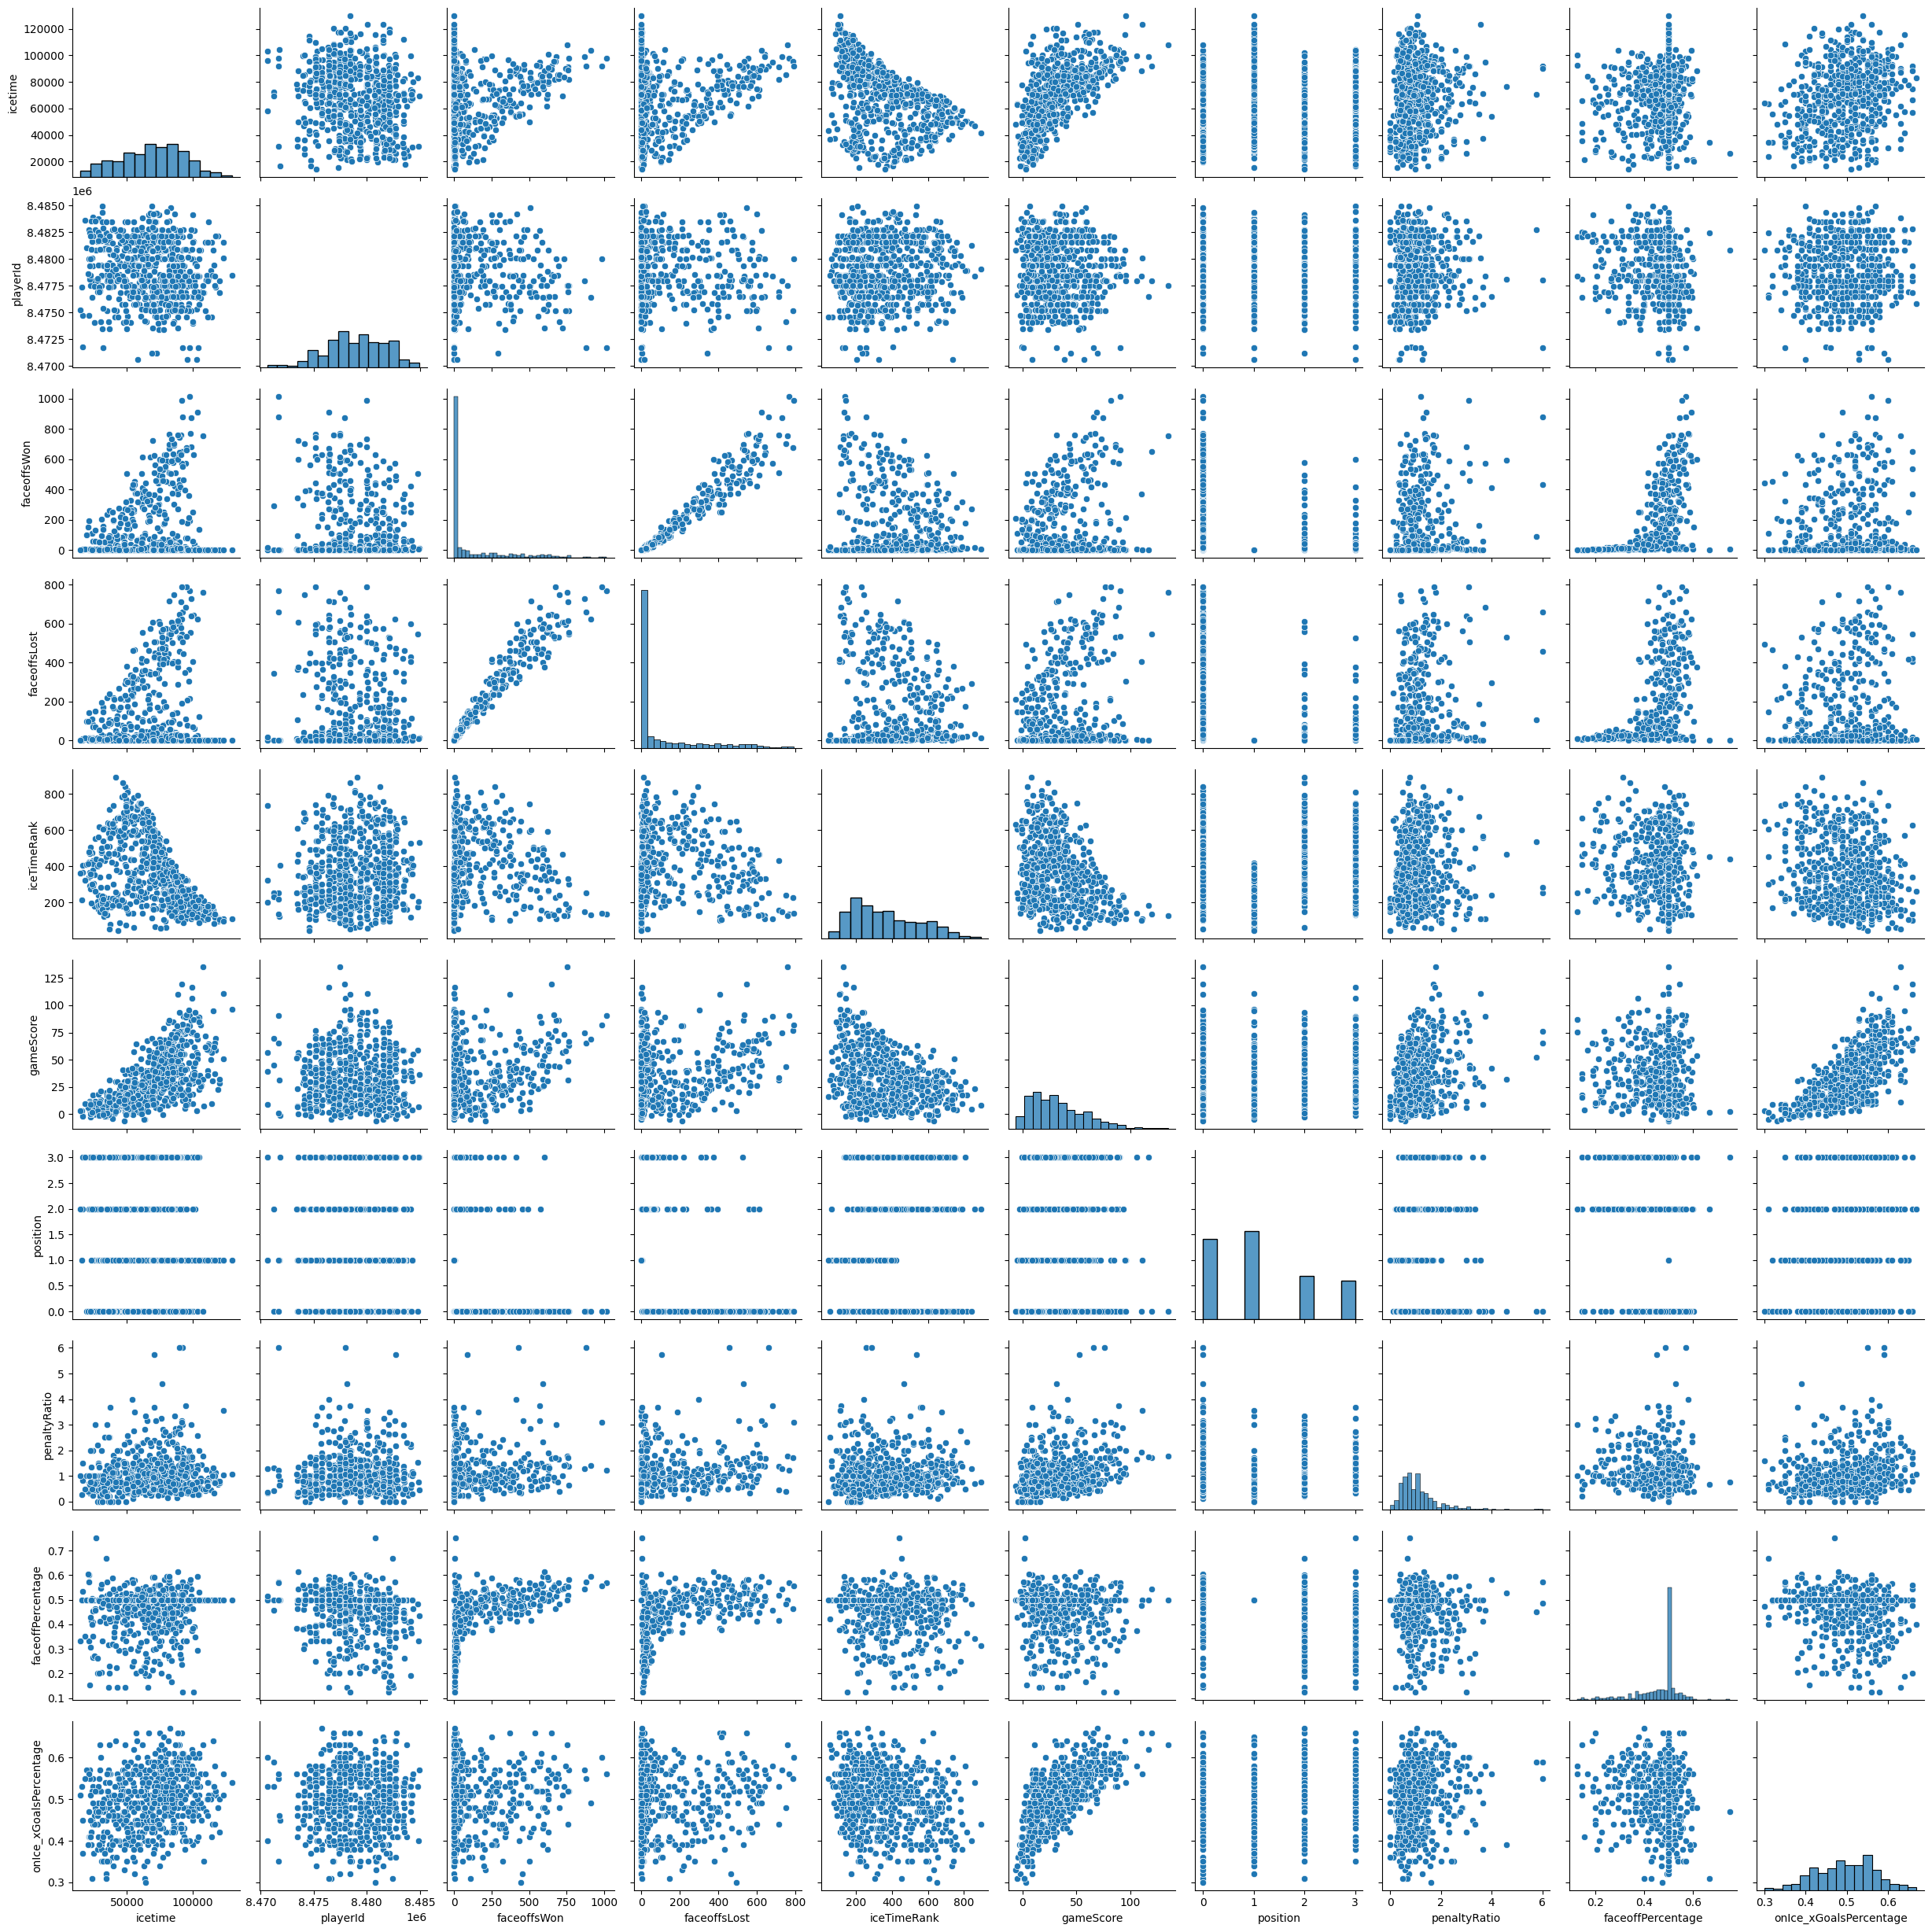

In [8]:
# Make pairplot of top 10 most variable features
variances = df.var().sort_values(ascending=False)
top_cols = variances.head(10).index
sns.pairplot(df[top_cols])

## Data summary
- Feature selection and engineering: Performed quite a bit of initial manual feature selection and subsequent feature engineering to prepare a dataset with rich, clean data for clustering.
- Correlations: There are certainly correlated features in this dataset. However we will be running Principal Component Analysis (PCA) which will deal with any issues caused by correlation, so we don't need to modify the data.
- Outliers: There was originally some outliers in Faceoff Percentage, so I cleaned the data to fix this. There are no other concerning outliers.
- Scaling and normalization: First we normalized many of the features by ice time, so that the features aren't heavily biased towards players who have played more time. We also applied a Standard Scaling across all features so that they are roughly scaled the same going into our unsupervised models.
- HYPOTHESIS: My hypothesis is that the clustering will be heavily dictated by positions (forwards vs defense), and also scoring productivity (there are a number of features that reflect scoring productivity)

## Model selection

We will use 2 unsupervised learning methods in serial to address this cluster problem

1. Since we have a large number of features (40+), it would be beneficial to do some dimensionality reduction before fitting a clustering model. Principle Component Analysis (PCA) is the perfect tool for this. We will use PCA to reduce the number of features that explain 90% of the variance of the data.
2. After reducing the dimensionality, we need to use a clustering model to generate the clusters. We want to use a model that is effective but not overly complicated, so we can use K Means clustering. We will do hyperparameter tuning on this to make sure we have an optimized model.

## Model 1: Use PCA to reduce dimensionality

In [9]:
# PCA to keep components explaining 90% variance
pca = PCA(n_components=0.90, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)
print("Original features:", df_scaled.shape[1])
print("Reduced features:", X_pca.shape[1])

Original features: 43
Reduced features: 15


We have reduced our number of features down to 14. This is a much more reasonable number of features to perform clustering on. By doing PCA, we have also eliminated any concerns about data correlation affecting our model performance.

## Model 2: Use K Means to cluster PCA data
Now we can take the output of the PCA dimensionality reduction and cluster via K Means.

## Hyperparameter Tuning: Number of clusters, k
We will use the elbow method and the silhouette score method to tune the number of clusters, k
- Elbow method: For each number of clusters, k, visualize the Within Cluster Sum of Squares (WCSS) to find if there is a significant elbow in the curve where the reduction in WCSS error levels off. WCSS will always decrease as we increase k.
- Silhouette score: Silhouette score measures cluster quality. It is a measure of how separated and compacted each cluster is. In this case we are looking for peaks in the curve to find good cluster quality.

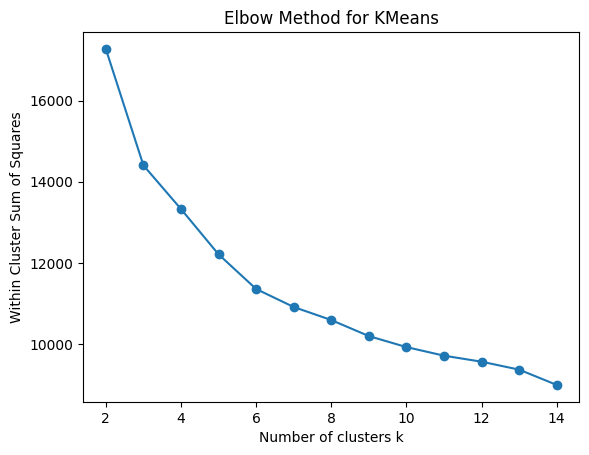

In [10]:
# K means elbow plot
sse = []
k_values = range(2, 15)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_pca)
    sse.append(km.inertia_)
plt.plot(k_values,sse, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Within Cluster Sum of Squares")
plt.title("Elbow Method for KMeans")
plt.show()


Text(0.5, 1.0, 'Silhouette for KMeans')

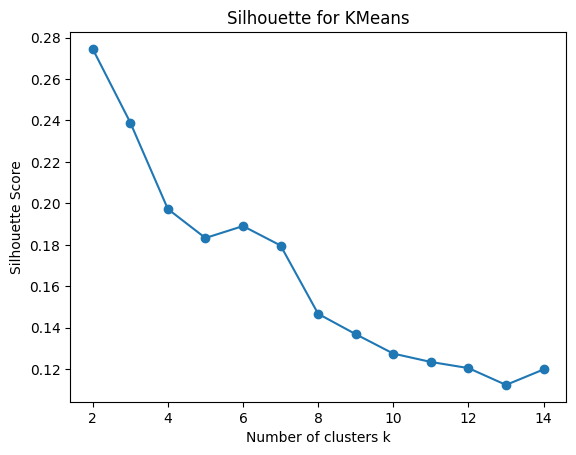

In [11]:
# Silhouette score
k_range = range(2, 15)
scores = []
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=0).fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))
plt.plot(range(2, 15), scores, marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette for KMeans")

- Since we are trying to generate interesting groupings of players, we probably want >5 clusters to find player groups that may show interesting and useful patterns.
- The elbow plot shows pretty consistent reduction in WCSS as k increases, there are no extremely obvious elbows. But I would say it looks like the curve starts to level off around k = 5-7.
- The silhouette score shows a significant spike at k = 6. There appears to be an increase in cluster quality for 6 clusters.
- Based on these two tuning plots, we will choose 6 clusters going forward. This should be enough groupings, but not too many, to yield interesting results.

## Hyperparameter Tuning: Other K Means hyperparameters
- We will make a custom class that can be used in a grid search cross validation, in order to tune the other K Means Hyperparameters

In [27]:
# Tune other K Means hyperparameters
class KM(KMeans, BaseEstimator):
    def score(self, X, y=None):
        labels = self.fit_predict(X)
        return silhouette_score(X, labels)

param_grid = {
    "init": ["k-means++", "random"],
    "n_init": [10, 20, 50],
    "max_iter": [300, 600],
    "algorithm": ["lloyd", "elkan"],
}

grid = GridSearchCV(
    estimator=KM(n_clusters=6, random_state=22),
    param_grid=param_grid,
    scoring=None,
    # cv=[(slice(None), slice(None))],
    n_jobs=-1,
    # verbose=1,
)
grid.fit(X_pca)

print("Best params:", grid.best_params_)
print("Best silhouette:", grid.best_score_)

# Assign labels to dataframe
labels = grid.best_estimator_.labels_
df_scaled['cluster'] = labels
df['cluster'] = labels

Best params: {'algorithm': 'lloyd', 'init': 'random', 'max_iter': 300, 'n_init': 50}
Best silhouette: 0.19830219389742682


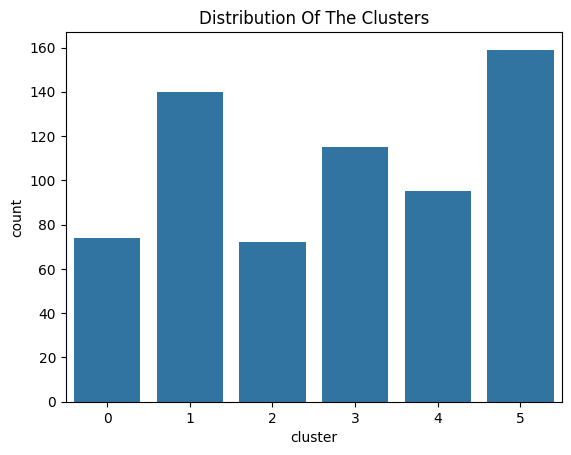

In [28]:
# Visualize clusters
pl = sns.countplot(x=df_scaled["cluster"])
pl.set_title("Distribution Of The Clusters")
plt.show()

The number of players between clusters is fairly well distributed. Cluster 1 and 5 have nearly double the players as some other clusters.

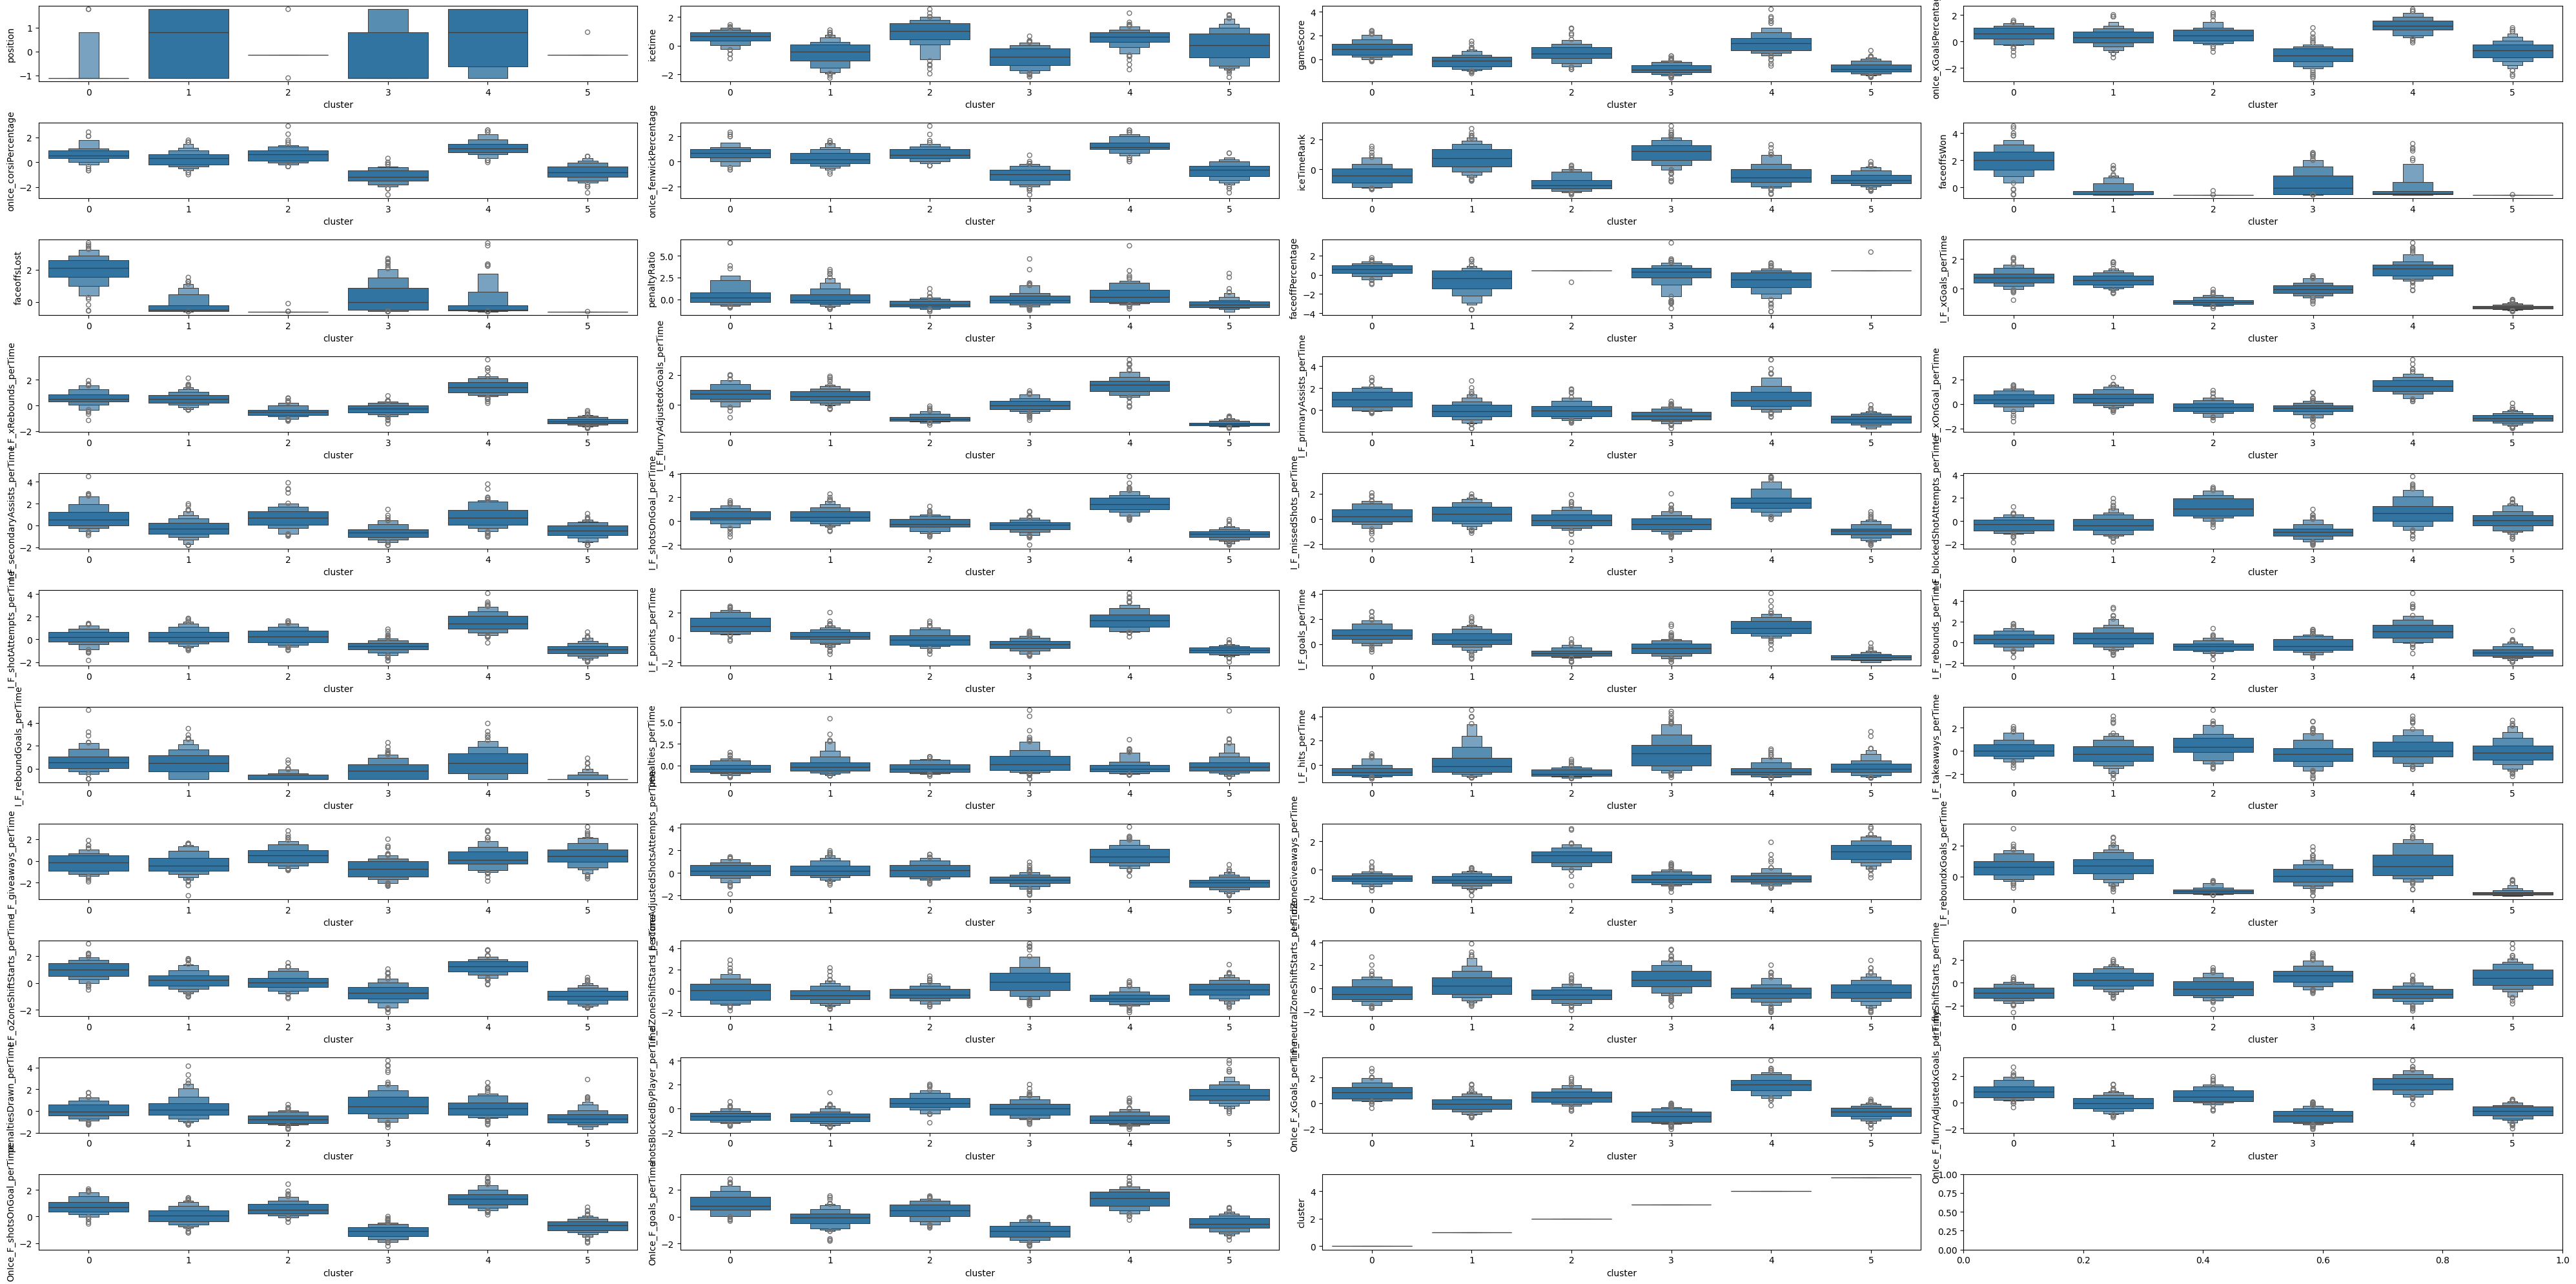

In [34]:
# Visualize cluster distribution within different features
df_no_id = df_scaled.drop(columns=['playerId'])
all_columns = list(df_no_id.columns)

fig, axes = plt.subplots(11, 4, figsize=(40,20))
for i, col in enumerate(all_columns):
    sns.boxenplot(data=df_no_id, x='cluster', y=col, ax=axes[int(np.floor(i/4)), i % 4])#.set_title(col)
fig.tight_layout()

This plot shows, for every single feature, what the distribution of different clusters for that feature. Although there is a lot of data in this plot, it's a good place to start to find interesting trends before digging in further.

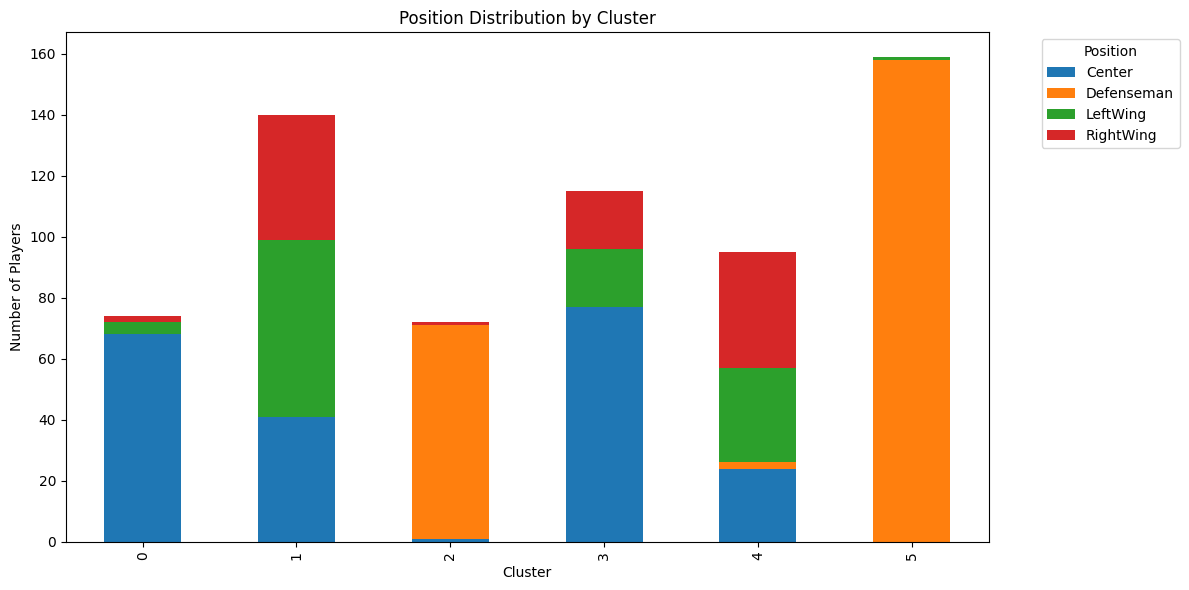

In [35]:
# Which positions are in each cluster?
df['position_str'] = df['position'].map({v: k for k, v in encoded_maps['position'].items()})
position_cluster = pd.crosstab(df['cluster'], df['position_str'])
position_cluster.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Cluster')
plt.ylabel('Number of Players')
plt.title('Position Distribution by Cluster')
plt.legend(title='Position', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


The clusters are pretty heavily influenced by position, as we expected in our original hypothesis. The position you play significantly affects your stats:
- Cluster 0 is composed of virtually all Centers
- Clusters 2 and 5 are virtually all defensemen
- Clusters 1, 3, and 4 are a variety of different forwards (Centers, Left, and Right Wings) who play different roles.

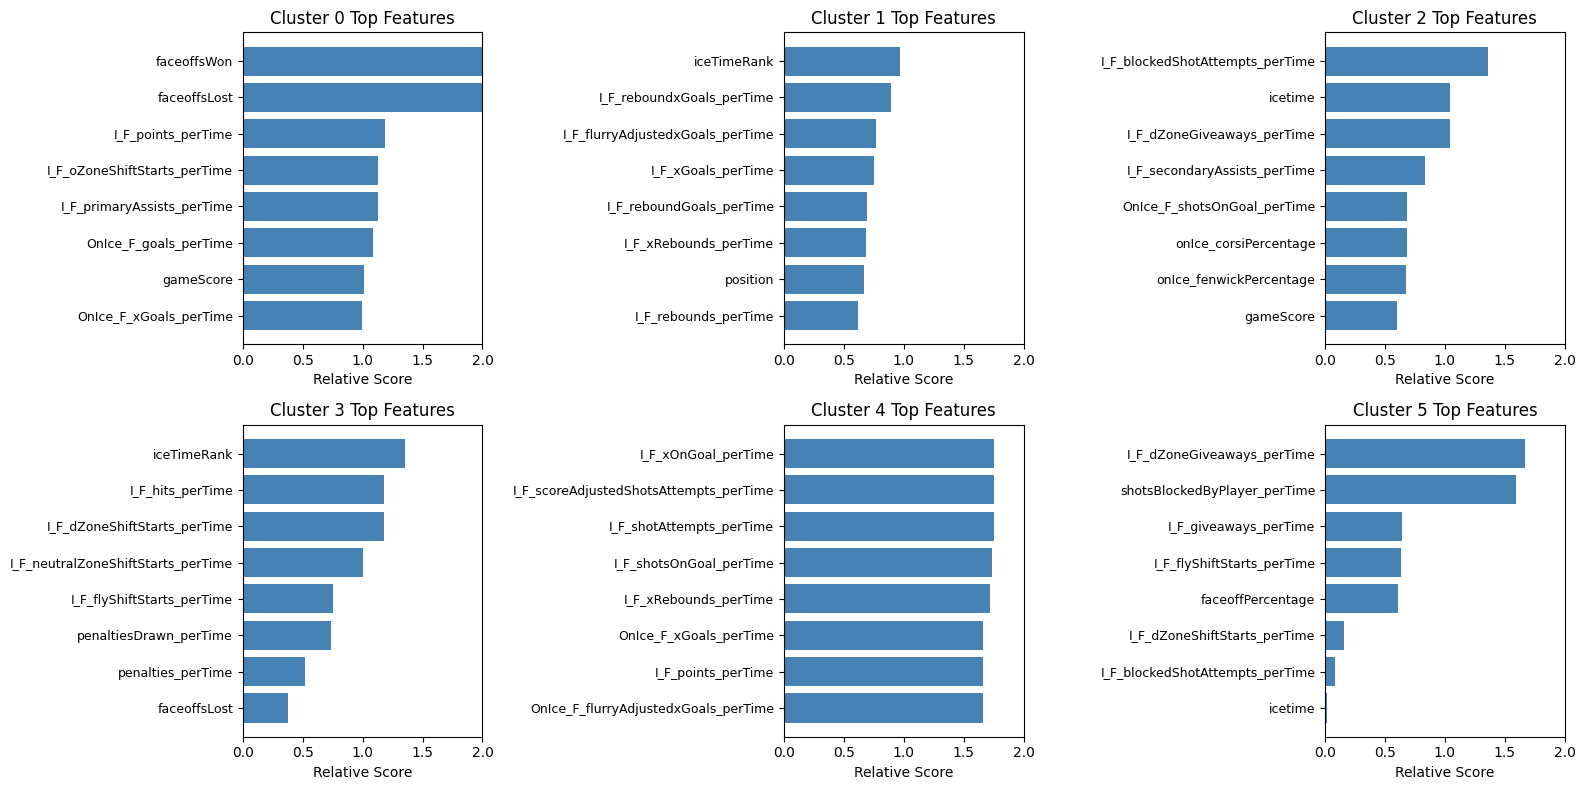

In [41]:
# For each cluster, what are the highest performing features
num_top_features = 8
clusters = df_no_id["cluster"].unique()
features = [c for c in df_no_id.columns if c != "cluster"]
relative_scores = {}
for c in clusters:
    in_cluster = df_no_id[df_no_id["cluster"] == c][features].mean()
    out_cluster = df_no_id[df_no_id["cluster"] != c][features].mean()
    
    diff = in_cluster - out_cluster
    relative_scores[c] = diff.sort_values(ascending=False)

# Plot top 5 features for each cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, cluster_id in enumerate(sorted(clusters)):
    top_features = relative_scores[cluster_id].head(num_top_features)
    axes[idx].barh(range(len(top_features)), top_features.values, color='steelblue')
    axes[idx].set_yticks(range(len(top_features)))
    axes[idx].set_yticklabels(top_features.index, fontsize=9)
    axes[idx].set_xlabel('Relative Score')
    axes[idx].set_title(f'Cluster {cluster_id} Top Features')
    axes[idx].invert_yaxis()
    axes[idx].set_xlim([0,2])

plt.tight_layout()
plt.show()

This plot is very illustrative for showing which types of players are in each cluster. We can now break down the archetype of player in each cluster.

Note: In 'iceTimeRank', a lower value means the player receives more ice time. A higher rank means the player doesn't play much.

Archetypes:
- CLUSTER 0: "Reliable Center" -- This cluster is composed of players who are likely the 2nd or 3rd Center on their team. They are good players who generate offensive productivity, while also being defensively responsible and taking faceoffs for their team.
- CLUSTER 1: "Average Forward" -- These forwards don't get a ton of ice team but they can generate valuable offensive productivity at times. Their rebound stats are particularly differentiating, showing the fact that they score mostly opportunistic rebound goals given their lack of skill. This group makes up the largest cluster of forwards in the league.
- CLUSTER 2: "Star Defenseman" -- The best defensemen in the league. They receive the most ice time of any players in the league. They are the best 1-2 defensemen on their team and can generate offensive productivity as a defensemen while shutting down the other team's best players.
- CLUSTER 3: "Fringe NHL player / Enforcer" -- These players get the least ice time in the league. They may be enforcers who get in fights, or they may be fringe NHL players trying to break into, or stay, in the league
- CLUSTER 4: "Star Forward" -- Absolute offensive powerhouses. The best forwards in the league who generate a massive number of offensive productivity. Primarily wings but also include elite offensive Centers.
- CLUSTER 5: "Average Defensemen" -- This category includes most of the defensemen in the league. Usually the 3-6 best defensemen on their teams. Can provide reliable defensive play with limited offense/posession skills.

In [37]:
# Create a dictionary of player lists for each cluster
df_scaled['playerId'] = df['playerId'].values
cluster_players = {}
for cluster_id in df_scaled['cluster'].unique():
    cluster_mask = df_scaled['cluster'] == cluster_id
    player_ids = df_scaled[cluster_mask]['playerId'].values
    player_names = [player_id_to_name[pid] for pid in player_ids]
    cluster_players[cluster_id] = player_names

# # View the result
# for cluster_id, players in cluster_players.items():
#     print(f"Cluster {cluster_id}: {len(players)} players")
#     print(players)

We can compare each player to the centroid of their cluster to determine the top 3 most representative players from their cluster.

In [38]:
# Most representative 3 players per cluster
top_k = 3
representatives = {}
embedding = df_scaled.drop(columns=['cluster','playerId']).values
for c in sorted(df_scaled['cluster'].unique()):
    mask = (df_scaled['cluster'] == c).values
    member_idx = np.where(mask)[0]
    if len(member_idx) == 0:
        representatives[c] = []
        continue

    centroid = embedding[member_idx].mean(axis=0)
    dists = np.linalg.norm(embedding[member_idx] - centroid, axis=1)
    nearest_order = np.argsort(dists)[:min(top_k, len(member_idx))]
    selected_positions = member_idx[nearest_order]

    representatives[c] = [
        player_id_to_name[int(df_scaled.iloc[pos]['playerId'])]
        for pos in selected_positions
    ]

# Show results
for c, names in representatives.items():
    print(f"Cluster {c}: {len(names)} representative(s) -> {names}")

Cluster 0: 3 representative(s) -> ['Marco Rossi', 'Anton Lundell', 'Sean Couturier']
Cluster 1: 3 representative(s) -> ['Joel Farabee', 'Andrew Mangiapane', 'Kaapo Kakko']
Cluster 2: 3 representative(s) -> ['Mattias Ekholm', 'Luke Hughes', 'Thomas Chabot']
Cluster 3: 3 representative(s) -> ['Nico Sturm', 'Joe Veleno', 'Casey Cizikas']
Cluster 4: 3 representative(s) -> ['William Nylander', 'Alex DeBrincat', 'Matvei Michkov']
Cluster 5: 3 representative(s) -> ['Albert Johansson', 'Nicolas Hague', 'Kevin Bahl']


The most representative players from their clusters are shown above. Although this likely doesn't mean much to those outside of NHL fans, it is a good qualitative check to hockey nerds (like myself) to gut check that those players logically belong in each of these archetypes.

## Conclusion
In this project we used PCA and K Means clustering to cluster NHL players into similar groups of players. Since this is unsupervised learning, we don't have labels to check the accuracy of our model performance. However we were able to cluster the players into clear, separate "archetypes" that seem to be a very logical grouping based on the feature data and previous knowledge of professional hockey.

The original hypothesis was that these groups would heavily influenced by position and offensive productivity. That proved to be true in the model results. There were other less expected findings such as high "rebound" stats being differentiating features for the "Average Forward" archetype.

In order to improve this clustering in the future, we could start by including data from multiple seasons. This would yield a richer dataset to perform the clustering with. It would likely help avoid any bias associated with this particular season. We could also consider different clustering methods, or move toward a "soft clustering" framework, where players could belong in multiple clusters.

## References
1. https://moneypuck.com/data.htm
2. https://hockey-graphs.com/2017/04/04/identifying-player-types-with-clustering/
3. https://www.kaggle.com/code/richard47/clustering-nhl-players
